# 10- Validation Metrics: Ground-Truth Evaluation

**Project:** Fintech Sentiment Intelligence Analysis
**Goal:** Replace *asserted* claims with *validated* ones. Until now the Severity
Engine and the "VADER missed 26%" claim had no human-labeled ground truth. This
notebook joins the 200 manually-labeled reviews back to the model predictions and
computes formal metrics:

1. **Severity Engine**- multi-class (1-5) precision/recall/F1 + Cohen's kappa, and
   the business-critical **binary high-severity detector** (severity >= 4).
2. **VADER**  negative-class recall on the *human-labeled* set (the honest version
   of the "hidden negative" claim).

**Inputs:** `data/labels/labels.csv` (from the Streamlit tool) **or** a filled-in
`data/labels/label_queue_blind.csv` (from Excel). **Outputs:** validation tables in
`outputs/tables/` and a confusion matrix in `outputs/charts/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score, precision_recall_fscore_support)

# Make src importable
sys.path.insert(0, os.path.abspath(".."))
from src.analysis import score_dataframe, SEVERITY_MAP

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("libraries loaded")

libraries loaded


## 1. Load ground-truth labels + model predictions

In [2]:
LABELS_DIR = "../data/labels"

# Prefer labels.csv (Streamlit tool); fall back to a filled blind queue (Excel).
labels_path = os.path.join(LABELS_DIR, "labels.csv")
blind_path  = os.path.join(LABELS_DIR, "label_queue_blind.csv")

if os.path.exists(labels_path) and os.path.getsize(labels_path) > 0:
    labels = pd.read_csv(labels_path)
    src = "labels.csv (Streamlit tool)"
else:
    labels = pd.read_csv(blind_path)
    src = "label_queue_blind.csv (Excel)"

# Keep only rows that actually have both human labels filled in.
labels = labels.dropna(subset=["true_sentiment", "true_severity"])
labels = labels[labels["true_sentiment"].astype(str).str.strip() != ""]
labels["true_severity"] = labels["true_severity"].astype(int)

print(f"Loaded {len(labels)} labeled reviews from {src}")
assert len(labels) > 0, (
    "No labels found yet. Label the 200 reviews first:\n"
    "  streamlit run dashboard/label_tool.py\n"
    "or fill true_sentiment / true_severity in data/labels/label_queue_blind.csv"
)

Loaded 200 labeled reviews from labels.csv (Streamlit tool)


In [3]:
# Score the full clean dataset with the SAME engine used everywhere, then
# restrict to the labeled review_ids so predictions and ground truth align 1:1.
scored = score_dataframe(pd.read_csv("../data/clean/all_apps_clean.csv"))
pred = scored[scored["review_id"].isin(labels["review_id"])][
    ["review_id", "app_name", "rating", "review_clean",
     "vader_sentiment", "severity_score", "severity_label",
     "is_hidden_negative", "is_high_severity"]
]

eval_df = labels.merge(pred, on="review_id", how="inner")
print(f"Matched {len(eval_df)} reviews for evaluation")
eval_df.head()

Matched 200 reviews for evaluation


,review_id,true_sentiment,true_severity,notes,app_name,rating,review_clean,vader_sentiment,severity_score,severity_label,is_hidden_negative,is_high_severity
0,cf528bb3-494c-465d-8291-c138a7777336,Positive,1,NaN,Chime,5,no fees so many features chime rocks,Negative,1,Low,False,False
1,f1edde65-f460-469f-bef1-2136ebc74fa8,Negative,5,NaN,Cash App,1,hater,Negative,1,Low,False,False
2,68f381c9-606f-4a71-a37d-5e96cfdd28f6,Negative,4,NaN,Cash App,3,very useful app as long as i was sending money...,Positive,5,Critical,False,True
3,93c370ea-133e-4f06-b1ea-d9dc6ef316c1,Negative,5,NaN,Venmo,1,i hate the fact that you have to send minimum ...,Negative,5,Critical,False,True
4,20b991b7-1a38-4040-8678-ef627a530f4d,Negative,4,NaN,PayPal,1,not so good,Negative,1,Low,False,False


## 2. Severity Engine-multi-class (1-5)

Per-class precision/recall/F1. **Macro-F1** treats the rare Critical class fairly;
**Cohen's kappa** measures agreement beyond chance.

In [4]:
y_true_sev = eval_df["true_severity"].astype(int)
y_pred_sev = eval_df["severity_score"].astype(int)

report = classification_report(y_true_sev, y_pred_sev, digits=3,
                               zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(classification_report(y_true_sev, y_pred_sev, digits=3, zero_division=0))
kappa = cohen_kappa_score(y_true_sev, y_pred_sev)
print(f"Cohen's kappa (multi-class): {kappa:.3f}")

os.makedirs("../outputs/tables", exist_ok=True)
report_df.to_csv("../outputs/tables/severity_validation_report.csv")
print("saved -> outputs/tables/severity_validation_report.csv")

              precision    recall  f1-score   support

           1      0.205     0.692     0.316        26
           2      0.000     0.000     0.000        18
           3      0.214     0.043     0.072        69
           4      0.156     0.167     0.161        42
           5      0.235     0.267     0.250        45

    accuracy                          0.200       200
   macro avg      0.162     0.234     0.160       200
weighted avg      0.186     0.200     0.156       200

Cohen's kappa (multi-class): 0.016
saved -> outputs/tables/severity_validation_report.csv


# Confusion Matrix

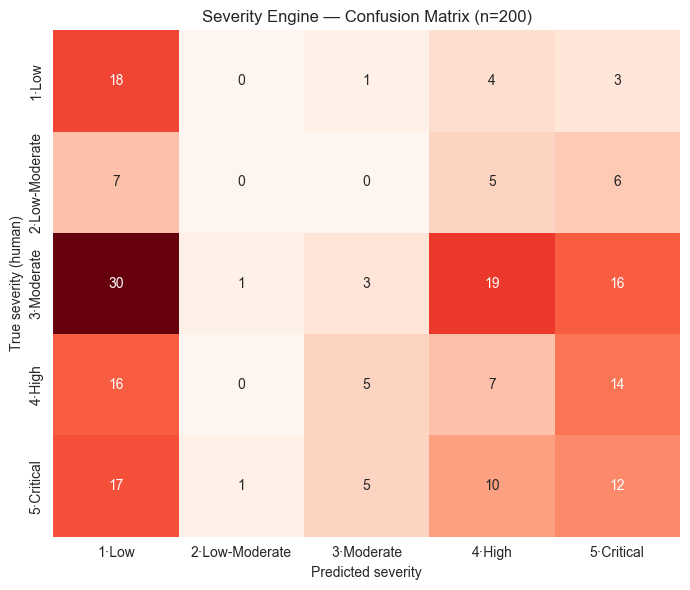

saved -> outputs/charts/severity_confusion_matrix.png


In [5]:
# 5x5 confusion matrix
labels_order = [1, 2, 3, 4, 5]
cm = confusion_matrix(y_true_sev, y_pred_sev, labels=labels_order)
tick = [f"{i}·{SEVERITY_MAP[i]}" for i in labels_order]

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=tick, yticklabels=tick, cbar=False)
plt.xlabel("Predicted severity"); plt.ylabel("True severity (human)")
plt.title("Severity Engine — Confusion Matrix (n=%d)" % len(eval_df))
plt.tight_layout()
os.makedirs("../outputs/charts", exist_ok=True)
plt.savefig("../outputs/charts/severity_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> outputs/charts/severity_confusion_matrix.png")

## 3. Binary high-severity detector (the business framing)

The $2-4M recovery estimate rests on one question: **can the engine reliably flag the
expensive complaints?** Collapse to `is_high_severity = severity >= 4` and report
precision (false-alarm cost) and recall (miss cost).

In [6]:
y_true_high = (eval_df["true_severity"] >= 4)
y_pred_high = (eval_df["severity_score"] >= 4)

p, r, f1, _ = precision_recall_fscore_support(
    y_true_high, y_pred_high, average="binary", zero_division=0)

high_tbl = pd.DataFrame({
    "metric": ["precision", "recall", "f1", "support (true highs)"],
    "value": [round(p, 3), round(r, 3), round(f1, 3), int(y_true_high.sum())],
})
print(high_tbl.to_string(index=False))
print(f"\nHIGH-SEVERITY DETECTOR: precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")
high_tbl.to_csv("../outputs/tables/high_severity_binary_metrics.csv", index=False)

              metric  value
           precision  0.448
              recall  0.494
                  f1  0.470
support (true highs) 87.000

HIGH-SEVERITY DETECTOR: precision=0.448  recall=0.494  f1=0.470


## 4. VADER validation — the honest "hidden negative" number

Confirm VADER's recall on the Negative class against the *human* labels. This replaces
the star-rating-only estimate with a defensible figure.

In [7]:
y_true_sent = eval_df["true_sentiment"]
y_pred_sent = eval_df["vader_sentiment"]

vader_report = classification_report(y_true_sent, y_pred_sent, digits=3,
                                     zero_division=0, output_dict=True)
print(classification_report(y_true_sent, y_pred_sent, digits=3, zero_division=0))
pd.DataFrame(vader_report).transpose().to_csv(
    "../outputs/tables/vader_validation_report.csv")

neg_recall = vader_report.get("Negative", {}).get("recall", float("nan"))
miss_rate = (1 - neg_recall) if neg_recall == neg_recall else float("nan")
print(f"\nVADER negative recall = {neg_recall:.1%}  ->  miss rate = {miss_rate:.1%}")
print("saved -> outputs/tables/vader_validation_report.csv")

              precision    recall  f1-score   support

    Negative      0.919     0.664     0.771       137
     Neutral      0.200     0.200     0.200        20
    Positive      0.481     0.907     0.629        43

    accuracy                          0.670       200
   macro avg      0.534     0.590     0.533       200
weighted avg      0.753     0.670     0.684       200


VADER negative recall = 66.4%  ->  miss rate = 33.6%
saved -> outputs/tables/vader_validation_report.csv


## 5. Evidence gallery — where VADER failed

Concrete "VADER said Neutral/Positive, human said Negative" cases. This makes the
hidden-negative problem visceral for a recruiter and feeds the dashboard's Validation page.

In [8]:
missed = eval_df[(eval_df["true_sentiment"] == "Negative") &
                 (eval_df["vader_sentiment"] != "Negative")].copy()
print(f"VADER missed {len(missed)} human-labeled negatives in the sample\n")
gallery = missed[["app_name", "rating", "vader_sentiment",
                  "true_severity", "review_clean"]].head(10)
gallery.to_csv("../outputs/tables/vader_missed_examples.csv", index=False)
for _, row in gallery.iterrows():
    print(f"[{row['app_name']} · {row['rating']}★ · VADER={row['vader_sentiment']}"
          f" · human sev={row['true_severity']}]")
    print(f"  \"{str(row['review_clean'])[:180]}\"\n")

VADER missed 46 human-labeled negatives in the sample

[Cash App · 3★ · VADER=Positive · human sev=4]
  "very useful app as long as i was sending money from my bank account but im pretty sure my credit card number got stolen when i used that instead of my bank account"

[PayPal · 1★ · VADER=Positive · human sev=5]
  "garbagei feel like an app thats accepted worldwide almost as the app we get free money with using mobile games shouldnt feel like its completely against youi have one paypal accoun"

[Venmo · 2★ · VADER=Positive · human sev=4]
  "usually didnt require help but when needed help is hard to get"

[Chime · 1★ · VADER=Neutral · human sev=5]
  "chime did not explain anything to me at all and told me that i couldnt do it"

[Venmo · 3★ · VADER=Positive · human sev=4]
  "sometime transactions go smoothly sometimes they seem to disappear as if they never happened frustrating"

[Venmo · 1★ · VADER=Positive · human sev=5]
  "adding money to your account they take it out of your bank a

In [9]:
macro_f1 = report["macro avg"]["f1-score"]
weighted_f1 = report["weighted avg"]["f1-score"]

summary = (
    f"VALIDATED ON {len(eval_df)} HUMAN-LABELED REVIEWS (stratified, seed=42)\n"
    f"{'='*62}\n"
    f"Severity Engine  : macro-F1 = {macro_f1:.2f} | weighted-F1 = {weighted_f1:.2f} "
    f"| kappa = {kappa:.2f}\n"
    f"High-severity    : precision = {p:.2f} | recall = {r:.2f} | f1 = {f1:.2f}\n"
    f"VADER negatives  : recall = {neg_recall:.0%}  ->  miss rate = {miss_rate:.0%}\n"
)
print(summary)
with open("../outputs/tables/validation_summary.txt", "w") as fh:
    fh.write(summary)
print("saved -> outputs/tables/validation_summary.txt")

# Honesty guardrail: report real numbers even if modest; document next steps if low.
if macro_f1 < 0.6:
    print("\nNOTE: macro-F1 < 0.60. Add a 'limitations & next steps' note "
          "(negation handling, expand lexicon) rather than overclaiming.")

VALIDATED ON 200 HUMAN-LABELED REVIEWS (stratified, seed=42)
Severity Engine  : macro-F1 = 0.16 | weighted-F1 = 0.16 | kappa = 0.02
High-severity    : precision = 0.45 | recall = 0.49 | f1 = 0.47
VADER negatives  : recall = 66%  ->  miss rate = 34%

saved -> outputs/tables/validation_summary.txt

NOTE: macro-F1 < 0.60. Add a 'limitations & next steps' note (negation handling, expand lexicon) rather than overclaiming.
